# CellOracle GRN Inference: Norman 2019 (K562) — v3

**Fixes from v2:**
1. Gene name mismatch: Ensembl IDs → gene symbols via `adata.var['gene_name']`
2. Single cell type: K562 ctrl cells assigned to one cluster, use `GRN_unit="whole"`
3. Embedding KeyError: check actual key in `obsm` instead of assuming `X_draw_graph_fa`

**Pipeline:** Bulk ATAC BED → TSS → motif scan → base GRN → Oracle (single cluster) → GRN → M matrix

In [1]:
import os
os.environ["PATH"] = "/conda_envs/celloracle_env/bin:" + os.environ["PATH"]

import importlib
import pybedtools
import pybedtools.bedtool
importlib.reload(pybedtools.bedtool)
importlib.reload(pybedtools)

# Verify bedtools
a = pybedtools.example_bedtool('a.bed')
b = pybedtools.example_bedtool('b.bed')
print(a.intersect(b))

chr1	155	200	feature2	0	+
chr1	155	200	feature3	0	-
chr1	900	901	feature4	0	+



In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
import celloracle as co
from celloracle import motif_analysis as ma

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams['savefig.dpi'] = 300

print(f"CellOracle version: {co.__version__}")

/conda_envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


CellOracle version: 0.20.0


In [3]:
# ============ ALL PATHS — EDIT HERE ============
BED_PATH    = "../../data/ATAC_Seq/K562/K562_ATAC_peaks.bed"
NORMAN_H5AD = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"
GENOMES_DIR = "../../data/genomes"
OUTPUT_DIR  = "./celloracle_grn/"
REF_GENOME  = "hg38"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for p, label in [(BED_PATH, 'BED'), (NORMAN_H5AD, 'Norman h5ad'),
                  (f"{GENOMES_DIR}/{REF_GENOME}/{REF_GENOME}.fa", 'Genome FASTA')]:
    assert os.path.exists(p), f"Missing {label}: {p}"
    print(f"OK: {label} -> {p}")

OK: BED -> ../../data/ATAC_Seq/K562/K562_ATAC_peaks.bed
OK: Norman h5ad -> ../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad
OK: Genome FASTA -> ../../data/genomes/hg38/hg38.fa


---
## 1. Bulk ATAC-seq → TSS Annotation

Steps 1.1–1.6 and 2.1–2.7 are unchanged from v2.  
**If you already have `K562_base_GRN.parquet`, skip to Section 3.**

In [4]:
# 1.1 Load BED
bed = ma.read_bed(BED_PATH)
print(f"Peaks loaded: {bed.shape[0]}")
bed.head()

Peaks loaded: 181340


,chrom,start,end,seqname
0,chr9,131124596,131126388,chr9_131124596_131126388
1,chr22,21641339,21643421,chr22_21641339_21643421
2,chr22,22507961,22509223,chr22_22507961_22509223
3,chr9,120868418,120869461,chr9_120868418_120869461
4,chr1,16612609,16614051,chr1_16612609_16614051


In [5]:
# 1.2 Convert to peak strings
peaks = ma.process_bed_file.df_to_list_peakstr(bed)
print(f"Total peaks: {len(peaks)}")

Total peaks: 181340


In [6]:
# 1.3 Symlink genome
default_genome_dir = os.path.expanduser(f"~/.local/share/genomes/{REF_GENOME}")
os.makedirs(default_genome_dir, exist_ok=True)

src_fa  = os.path.abspath(f"{GENOMES_DIR}/{REF_GENOME}/{REF_GENOME}.fa")
src_fai = os.path.abspath(f"{GENOMES_DIR}/{REF_GENOME}/{REF_GENOME}.fa.fai")

for src in [src_fa, src_fai]:
    dst = os.path.join(default_genome_dir, os.path.basename(src))
    if not os.path.exists(dst):
        os.symlink(src, dst)
        print(f"Symlinked: {dst}")
    else:
        print(f"Already exists: {dst}")

sizes_file = os.path.join(default_genome_dir, f"{REF_GENOME}.fa.sizes")
if not os.path.exists(sizes_file):
    fai = pd.read_csv(src_fai, sep='\t', header=None, usecols=[0,1], names=['chrom','size'])
    fai.to_csv(sizes_file, sep='\t', header=False, index=False)
    print(f"Created: {sizes_file}")

Already exists: /home/users/astar/imcb/hudh/.local/share/genomes/hg38/hg38.fa
Already exists: /home/users/astar/imcb/hudh/.local/share/genomes/hg38/hg38.fa.fai


In [7]:
# 1.4 TSS annotation
tss_annotated = ma.get_tss_info(peak_str_list=peaks, ref_genome=REF_GENOME)
print(f"TSS-annotated peaks: {tss_annotated.shape[0]}")

que bed peaks: 181340
tss peaks in que: 67318
TSS-annotated peaks: 67318


In [8]:
# 1.5 Format for motif scan
peak_id_tss = ma.process_bed_file.df_to_list_peakstr(tss_annotated)
tss_annotated_df = pd.DataFrame({
    "peak_id": peak_id_tss,
    "gene_short_name": tss_annotated.gene_short_name.values
}).reset_index(drop=True)

print(f"Peak-gene pairs: {tss_annotated_df.shape[0]}")
print(f"Unique genes: {tss_annotated_df['gene_short_name'].nunique()}")

Peak-gene pairs: 67318
Unique genes: 15344


In [9]:
# 1.6 Save checkpoint
tss_path = os.path.join(OUTPUT_DIR, "K562_processed_peak_file.csv")
tss_annotated_df.to_csv(tss_path, index=False)
print(f"Saved: {tss_path}")

Saved: ./celloracle_grn/K562_processed_peak_file.csv


---
## 2. TF Motif Scan → Base GRN

~3-30 min depending on CPU.

In [10]:
# 2.1 Instantiate TFinfo
tfi = ma.TFinfo(
    peak_data_frame=tss_annotated_df,
    ref_genome=REF_GENOME,
    genomes_dir=GENOMES_DIR
)
print("TFinfo created.")

TFinfo created.


In [11]:
%%time
# 2.2 Motif scan
tfi.scan(fpr=0.02, motifs=None, verbose=True, n_cpus=10)

No motif data entered. Loading default motifs for your species ...
 Default motif for vertebrate: gimme.vertebrate.v5.0. 
 For more information, please see https://gimmemotifs.readthedocs.io/en/master/overview.html 

Initiating scanner... 



2026-03-05 21:36:59,779 - DEBUG - using background: genome hg38 with size 200


Calculating FPR-based threshold. This step may take substantial time when you load a new ref-genome. It will be done quicker on the second time. 

Motif scan started .. It may take long time.



Scanning:   0%|          | 0/15691 [00:00<?, ? sequences/s]

CPU times: user 1min 56s, sys: 14.9 s, total: 2min 11s
Wall time: 3min 10s


In [12]:
# 2.3 Save motif scan checkpoint
tfi_path = os.path.join(OUTPUT_DIR, "K562_TFinfo.celloracle.tfinfo")
tfi.save_as_parquet(tfi_path)
print(f"Checkpoint: {tfi_path}")

file saved in: ./celloracle_grn/K562_TFinfo.celloracle.tfinfo
Checkpoint: ./celloracle_grn/K562_TFinfo.celloracle.tfinfo


In [13]:
# (Reload from checkpoint if needed)
# tfi = ma.load_TFinfo_from_parquets(os.path.join(OUTPUT_DIR, "K562_TFinfo.celloracle.tfinfo"))

In [14]:
# 2.4 Filter and build base GRN
tfi.reset_filtering()
tfi.filter_motifs_by_score(threshold=10)
tfi.make_TFinfo_dataframe_and_dictionary(verbose=True)

Filtering finished: 11349925 -> 2219914
1. Converting scanned results into one-hot encoded dataframe.


  0%|          | 0/15690 [00:00<?, ?it/s]

2. Converting results into dictionaries.


  0%|          | 0/15344 [00:00<?, ?it/s]

  0%|          | 0/1093 [00:00<?, ?it/s]

In [15]:
# 2.5 Extract and save base GRN
base_GRN_df = tfi.to_dataframe()
print(f"Base GRN: {base_GRN_df.shape[0]} peaks x {base_GRN_df.shape[1]-2} TFs")
base_GRN_df.to_parquet(os.path.join(OUTPUT_DIR, "K562_base_GRN.parquet"))
print("Base GRN saved.")

Base GRN: 17790 peaks x 1093 TFs
Base GRN saved.


---
## 3. Prepare Norman 2019 scRNA-seq

**Key fixes:**
- Convert Ensembl IDs → gene symbols
- Use only `ctrl` cells (pure control, not `gene+ctrl`)
- Single cluster for K562

In [16]:
# 3.1 Load
adata = sc.read_h5ad(NORMAN_H5AD)
print(f"Full data: {adata.shape}")
print(f"var_names (expect Ensembl IDs): {adata.var_names[:3].tolist()}")
print(f"var columns: {list(adata.var.columns)}")

Full data: (89357, 5045)
var_names (expect Ensembl IDs): ['ENSG00000239945', 'ENSG00000223764', 'ENSG00000187634']
var columns: ['gene_name']


In [17]:
# 3.2 FIX 1: Swap Ensembl IDs → Gene Symbols
# Identify the column containing gene symbols
symbol_col = None
for col in ['gene_name', 'gene_symbols', 'symbol', 'gene_short_name']:
    if col in adata.var.columns:
        symbol_col = col
        break

if symbol_col is None:
    # If no symbol column, check if var_names are already symbols
    if not adata.var_names[0].startswith('ENSG'):
        print("var_names already appear to be gene symbols.")
    else:
        raise ValueError("No gene symbol column found. Available: " + str(list(adata.var.columns)))
else:
    print(f"Using '{symbol_col}' for gene symbols")
    adata.var['ensembl_id'] = adata.var.index.copy()  # preserve Ensembl IDs
    adata.var.set_index(symbol_col, inplace=True)
    adata.var_names_make_unique()
    print(f"After fix: {adata.var_names[:5].tolist()}")

Using 'gene_name' for gene symbols
After fix: ['RP11-34P13.8', 'RP11-54O7.3', 'SAMD11', 'PERM1', 'HES4']


In [18]:
# 3.3 Subset to PURE control cells only (not gene+ctrl single perturbations)
adata_ctrl = adata[adata.obs['condition'] == 'ctrl'].copy()
print(f"Pure ctrl cells: {adata_ctrl.shape[0]}")

Pure ctrl cells: 7353


In [19]:
# 3.4 Verify raw counts
if sp.issparse(adata_ctrl.X):
    sample = adata_ctrl.X[:5, :5].toarray()
else:
    sample = adata_ctrl.X[:5, :5]
print(f"Sample (expect integers):\n{sample}")
print(f"Max: {adata_ctrl.X.max():.1f}, dtype: {adata_ctrl.X.dtype}")

Sample (expect integers):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]
Max: 2605.0, dtype: float32


In [20]:
# 3.5 Preprocess
adata_co = adata_ctrl.copy()
adata_co.layers['raw_count'] = adata_co.X.copy()

sc.pp.normalize_total(adata_co, target_sum=1e4)
sc.pp.log1p(adata_co)
sc.pp.highly_variable_genes(adata_co, n_top_genes=3000)
print(f"HVGs: {adata_co.var['highly_variable'].sum()}")

adata_co = adata_co[:, adata_co.var['highly_variable']].copy()
print(f"After HVG: {adata_co.shape}")

HVGs: 3000
After HVG: (7353, 3000)


In [21]:
# 3.6 FIX 2: Single cluster for K562 (one cell type)
adata_co.obs['cluster'] = 'K562'
adata_co.obs['cluster'] = adata_co.obs['cluster'].astype('category')
print(f"Clusters: {adata_co.obs['cluster'].value_counts().to_dict()}")

Clusters: {'K562': 7353}


In [22]:
# 3.7 PCA + neighbors + embedding
sc.pp.scale(adata_co, max_value=10)
sc.tl.pca(adata_co, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(adata_co, n_neighbors=15, n_pcs=30)

# Compute force-directed layout
sc.tl.draw_graph(adata_co)

# FIX 3: Check which embedding key was actually created
embedding_keys = [k for k in adata_co.obsm.keys() if 'draw_graph' in k]
print(f"Available draw_graph embeddings: {embedding_keys}")

if 'X_draw_graph_fa' in adata_co.obsm:
    EMBEDDING_NAME = 'X_draw_graph_fa'
elif 'X_draw_graph_fr' in adata_co.obsm:
    EMBEDDING_NAME = 'X_draw_graph_fr'
else:
    # Fallback: use PCA (embedding only needed for perturbation simulation, not GRN inference)
    EMBEDDING_NAME = 'X_pca'

print(f"Using embedding: {EMBEDDING_NAME}")

Available draw_graph embeddings: ['X_draw_graph_fr']
Using embedding: X_draw_graph_fr


In [23]:
# 3.8 Downsample if needed
if adata_co.shape[0] > 30000:
    sc.pp.subsample(adata_co, n_obs=30000, random_state=42)
    print(f"Downsampled to {adata_co.shape[0]}")
print(f"Final: {adata_co.shape}")

Final: (7353, 3000)


---
## 4. CellOracle GRN Inference

In [24]:
# 4.1 Load base GRN
base_GRN_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "K562_base_GRN.parquet"))
# Fallback: base_GRN_df = co.data.load_human_promoter_base_GRN()
print(f"Base GRN: {base_GRN_df.shape}")

Base GRN: (17790, 1095)


In [25]:
# 4.2 Verify gene name overlap BEFORE creating Oracle
grn_genes = set(base_GRN_df['gene_short_name'])
adata_genes = set(adata_co.var_names)
overlap = grn_genes & adata_genes
print(f"Base GRN genes: {len(grn_genes)}")
print(f"adata genes: {len(adata_genes)}")
print(f"Overlap: {len(overlap)}")

if len(overlap) == 0:
    print("\nWARNING: Zero overlap!")
    print(f"  adata sample: {list(adata_genes)[:5]}")
    print(f"  GRN sample: {list(grn_genes)[:5]}")
    raise ValueError("Gene name mismatch — check Ensembl vs symbol conversion above.")
else:
    print(f"OK: {len(overlap)} genes overlap ({len(overlap)/len(adata_genes)*100:.1f}% of adata)")

Base GRN genes: 15344
adata genes: 3000
Overlap: 1513
OK: 1513 genes overlap (50.4% of adata)


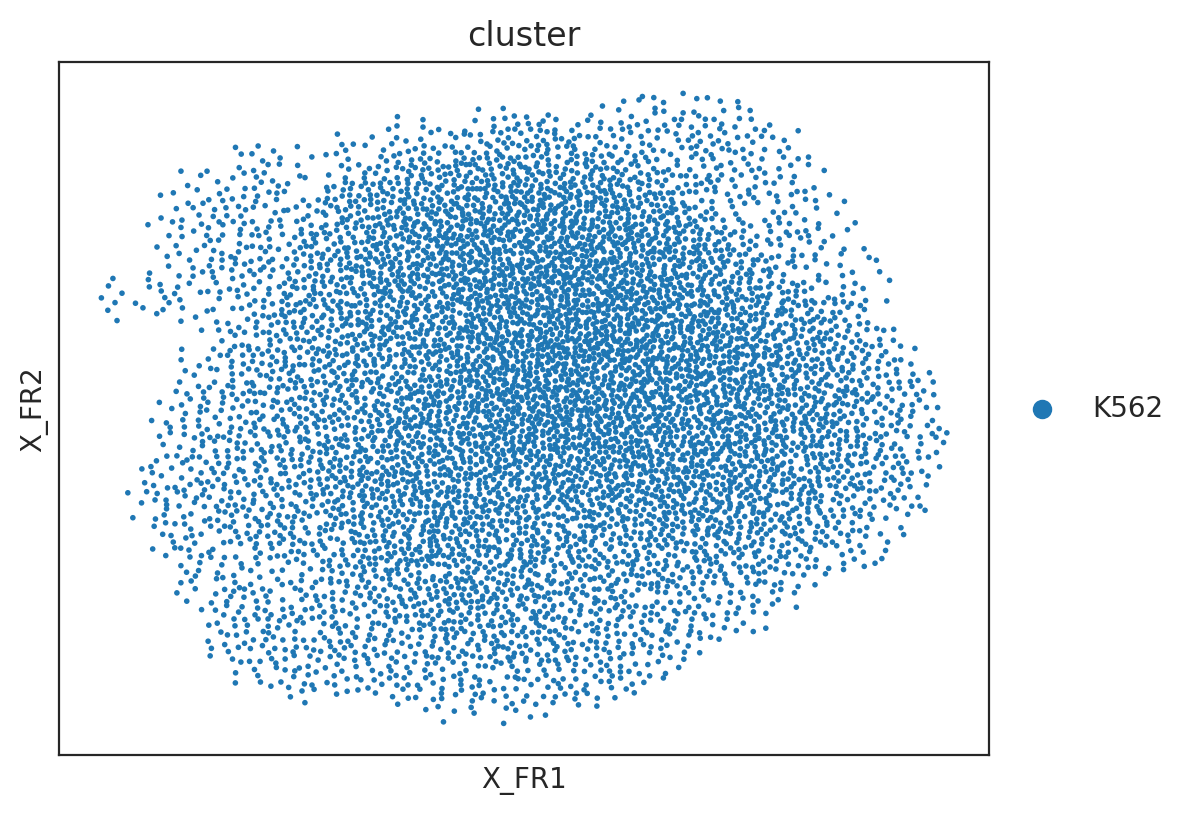

Oracle created.


In [26]:
# 4.3 Create Oracle
oracle = co.Oracle()

# Must set X to raw counts for import
adata_co.X = adata_co.layers['raw_count'].copy()

oracle.import_anndata_as_raw_count(
    adata=adata_co,
    cluster_column_name="cluster",
    embedding_name=EMBEDDING_NAME
)
print("Oracle created.")

In [27]:
# 4.4 Import base GRN
oracle.import_TF_data(TF_info_matrix=base_GRN_df)
print(oracle)

Oracle object

Meta data
    celloracle version used for instantiation: 0.20.0
    n_cells: 7353
    n_genes: 3000
    cluster_name: cluster
    dimensional_reduction_name: X_draw_graph_fr
    n_target_genes_in_TFdict: 15344 genes
    n_regulatory_in_TFdict: 1093 genes
    n_regulatory_in_both_TFdict_and_scRNA-seq: 131 genes
    n_target_genes_both_TFdict_and_scRNA-seq: 1513 genes
    k_for_knn_imputation: NA
Status
    Gene expression matrix: Ready
    BaseGRN: Ready
    PCA calculation: Not finished
    Knn imputation: Not finished
    GRN calculation for simulation: Not finished



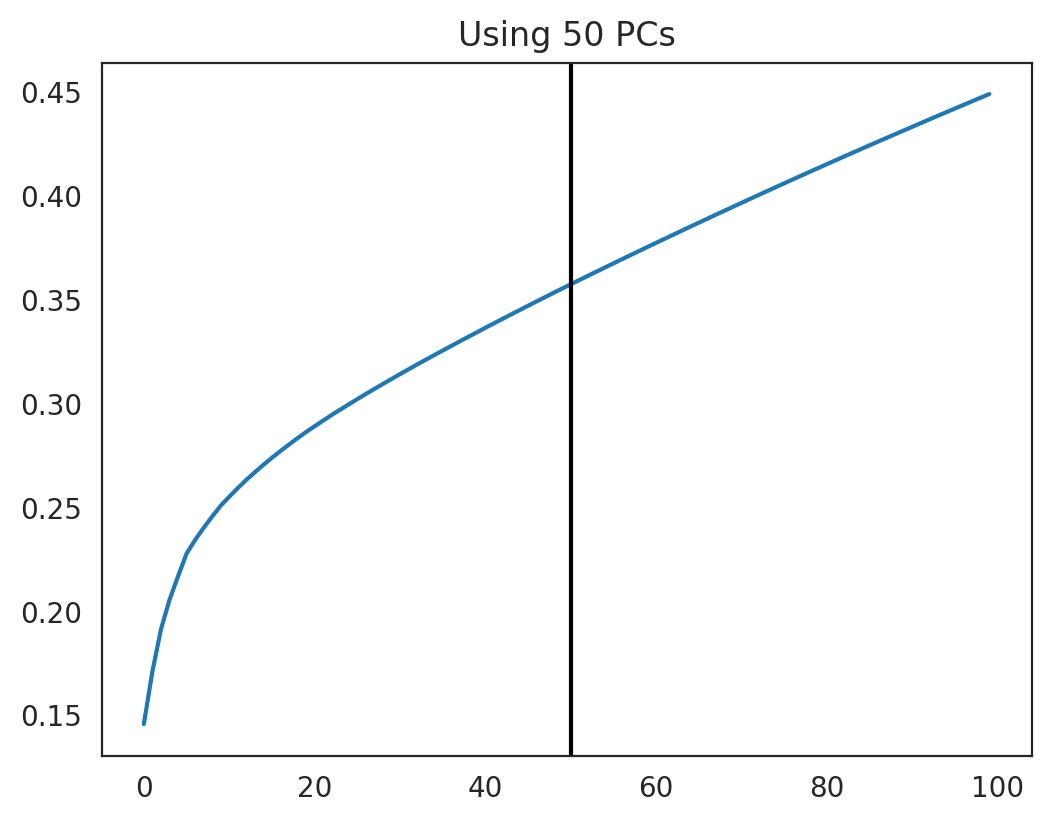

In [28]:
# 4.5 PCA for KNN
oracle.perform_PCA()
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(
    np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_)) > 0.002)
)[0][0]
n_comps = min(max(n_comps, 10), 50)
plt.axvline(n_comps, c="k")
plt.title(f"Using {n_comps} PCs")
plt.show()

In [29]:
# 4.6 KNN imputation
n_cell = oracle.adata.shape[0]
k = max(int(0.025 * n_cell), 30)
print(f"n_cell={n_cell}, k={k}")
oracle.knn_imputation(
    n_pca_dims=n_comps, k=k, balanced=True,
    b_sight=k*8, b_maxl=k*4, n_jobs=4
)
print("KNN imputation done.")

n_cell=7353, k=183
KNN imputation done.


In [30]:
# 4.7 Checkpoint
oracle_path = os.path.join(OUTPUT_DIR, "K562_norman.celloracle.oracle")
oracle.to_hdf5(oracle_path)
print(f"Saved: {oracle_path}")
# Reload: oracle = co.load_hdf5(oracle_path)

Saved: ./celloracle_grn/K562_norman.celloracle.oracle


In [31]:
%%time
# 4.8 GRN inference — single cluster ("whole")
# Since K562 is one cell type, we use all cells as one unit
links = oracle.get_links(
    cluster_name_for_GRN_unit="cluster",
    alpha=10,
    verbose_level=10
)
print("GRN inference done.")

  0%|          | 0/1 [00:00<?, ?it/s]

Inferring GRN for K562...


  0%|          | 0/1513 [00:00<?, ?it/s]

GRN inference done.
CPU times: user 1min 8s, sys: 4.7 s, total: 1min 13s
Wall time: 2min 30s


In [32]:
# 4.9 Inspect
print(f"Clusters in links: {list(links.links_dict.keys())}")
for cname, grn in links.links_dict.items():
    print(f"  '{cname}': {grn.shape[0]} edges")
    print(f"    columns: {list(grn.columns)}")
    display(grn.head(3))

Clusters in links: ['K562']
  'K562': 48783 edges
    columns: ['source', 'target', 'coef_mean', 'coef_abs', 'p', '-logp']


,source,target,coef_mean,coef_abs,p,-logp
0,CEBPB,AAK1,-0.000883,0.000883,3.943688e-01,0.404097
1,JUN,AAK1,0.008350,0.008350,1.426784e-08,7.845642
2,MEF2C,AAK1,0.027815,0.027815,3.448424e-17,16.462379


In [33]:
# 4.10 Filter + save links
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)
links_path = os.path.join(OUTPUT_DIR, "K562_norman.celloracle.links")
links.to_hdf5(links_path)
print(f"Links saved: {links_path}")

Links saved: ./celloracle_grn/K562_norman.celloracle.links


---
## 5. Extract GRN Matrix M

In [34]:
# 5.1 Since we have only one cluster ('K562'), extract directly
cluster_name = list(links.links_dict.keys())[0]
grn_df = links.filtered_links[cluster_name].copy()
print(f"Filtered edges for '{cluster_name}': {grn_df.shape[0]}")
print(f"Columns: {list(grn_df.columns)}")
grn_df.head()

Filtered edges for 'K562': 2000
Columns: ['source', 'target', 'coef_mean', 'coef_abs', 'p', '-logp']


,source,target,coef_mean,coef_abs,p,-logp
33367,ENO1,PRDX1,0.513066,0.513066,1.091014e-23,22.962170
19061,MYC,HIST1H4C,0.489923,0.489923,6.009549e-14,13.221158
19072,HOXB2,HIST1H4C,0.453442,0.453442,1.759498e-15,14.754611
17578,ENO1,GSTP1,0.445996,0.445996,2.256169e-24,23.646628
23613,ENO1,LDHA,0.440530,0.440530,5.815199e-30,29.235435


In [35]:
# 5.2 Build M matrix (TF → target, signed coefficients)
M_matrix = grn_df.pivot_table(
    index='target', columns='source',
    values='coef_mean', fill_value=0.0
)
print(f"M shape: {M_matrix.shape} (targets x TFs)")
print(f"Non-zero: {(M_matrix != 0).sum().sum()}")
print(f"Sparsity: {1 - (M_matrix != 0).sum().sum() / M_matrix.size:.4f}")

M shape: (291, 99) (targets x TFs)
Non-zero: 2000
Sparsity: 0.9306


In [36]:
# 5.3 Save
M_matrix.to_csv(os.path.join(OUTPUT_DIR, "K562_GRN_M_matrix.csv"))
np.save(os.path.join(OUTPUT_DIR, "K562_GRN_M_matrix.npy"), M_matrix.values)
pd.Series(M_matrix.index, name='target_gene').to_csv(
    os.path.join(OUTPUT_DIR, "K562_GRN_M_target_genes.csv"), index=False)
pd.Series(M_matrix.columns, name='source_TF').to_csv(
    os.path.join(OUTPUT_DIR, "K562_GRN_M_source_TFs.csv"), index=False)
grn_df.to_csv(os.path.join(OUTPUT_DIR, "K562_GRN_edges.csv"), index=False)

print(f"All saved to {OUTPUT_DIR}:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

All saved to ./celloracle_grn/:
  K562_GRN_M_matrix.csv
  K562_GRN_M_matrix.npy
  K562_GRN_M_source_TFs.csv
  K562_GRN_M_target_genes.csv
  K562_GRN_edges.csv
  K562_TFinfo.celloracle.tfinfo
  K562_base_GRN.parquet
  K562_norman.celloracle.links
  K562_norman.celloracle.oracle
  K562_processed_peak_file.csv


---
## 6. Sanity Checks

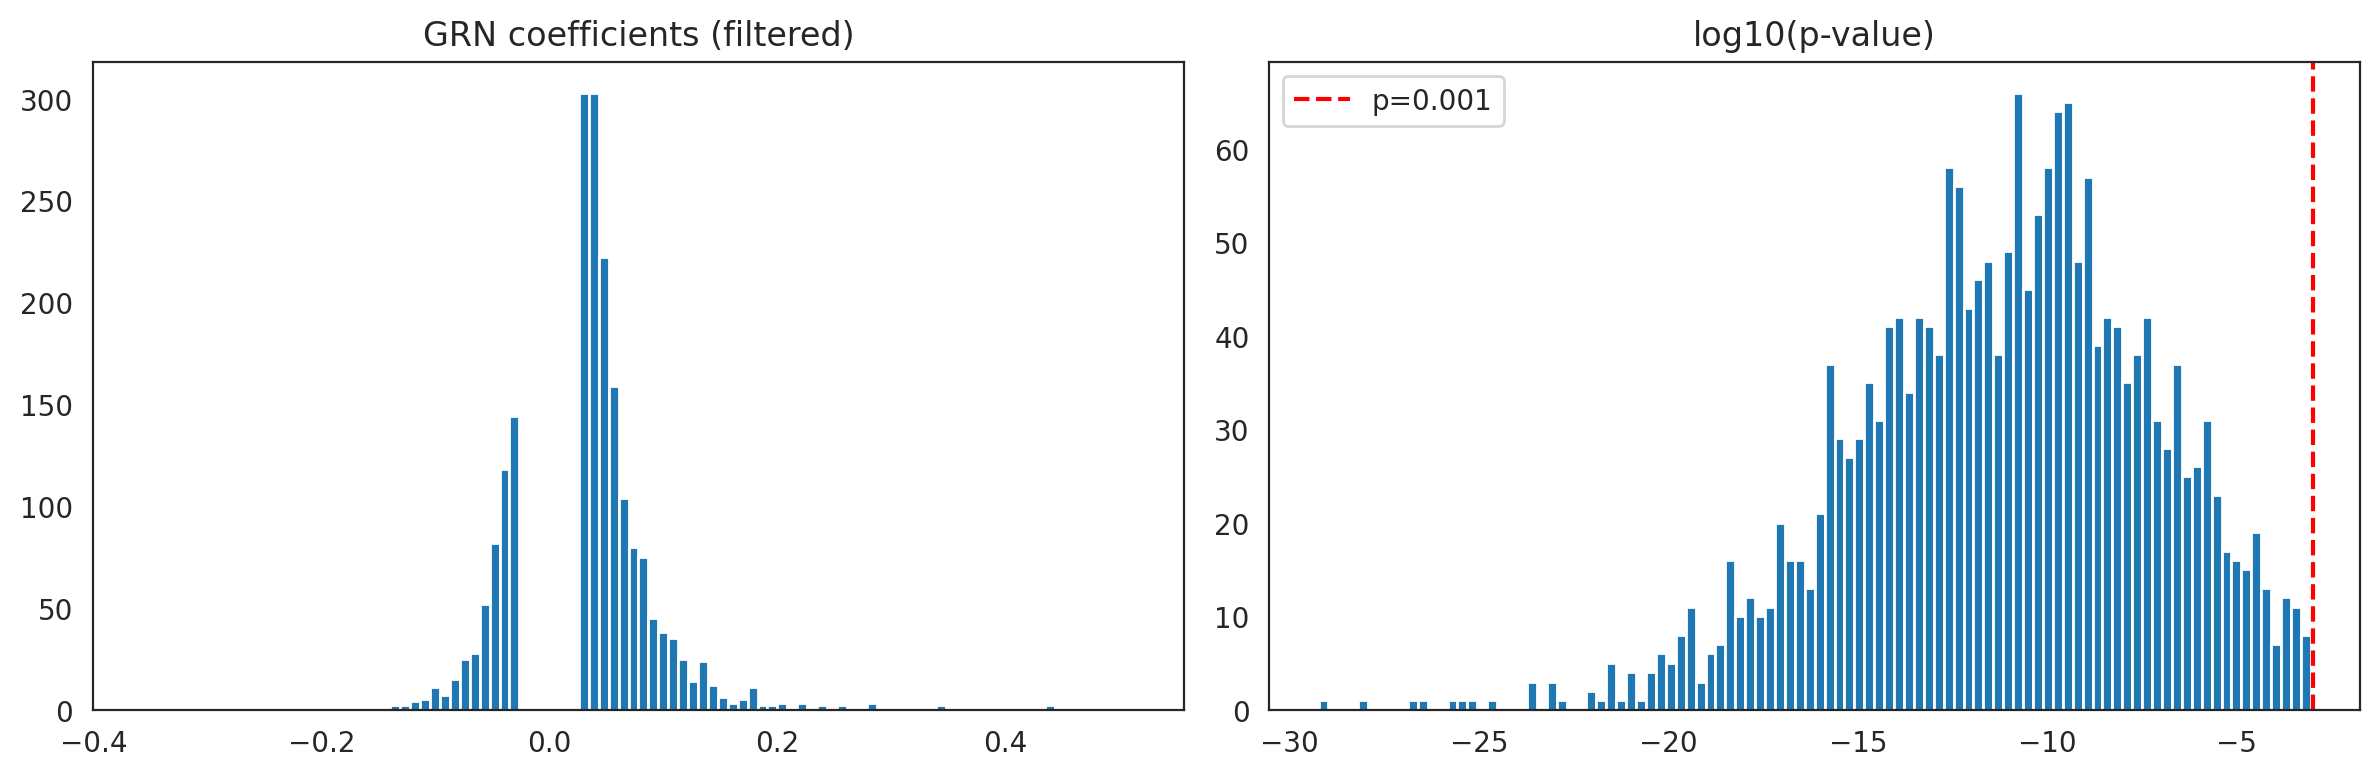

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(grn_df['coef_mean'], bins=100)
axes[0].set_title('GRN coefficients (filtered)')
axes[1].hist(np.log10(grn_df['p'] + 1e-300), bins=100)
axes[1].axvline(np.log10(0.001), c='r', ls='--', label='p=0.001')
axes[1].set_title('log10(p-value)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [38]:
# Top TFs by out-degree
tf_degree = grn_df.groupby('source')['target'].nunique().sort_values(ascending=False)
print("Top 20 TFs (# targets):")
print(tf_degree.head(20))

Top 20 TFs (# targets):
source
HES4       97
MYC        85
MEF2C      83
BHLHE40    79
KLF6       79
CHD2       74
ETS2       71
SPI1       68
EGR1       63
FEV        62
JUND       60
GATA2      55
FOS        54
HES1       53
FOXL2      50
ZEB1       46
TFAP2A     45
ENO1       40
CEBPB      36
CREB3L2    36
Name: target, dtype: int64


In [39]:
# Overlap with Norman perturbed genes
adata_full = sc.read_h5ad(NORMAN_H5AD)

# Convert full adata gene names too
if symbol_col and symbol_col in adata_full.var.columns:
    adata_full.var.set_index(symbol_col, inplace=True)
    adata_full.var_names_make_unique()

perturbed_genes = set()
for c in adata_full.obs['condition'].unique():
    if c != 'ctrl':
        for g in c.split('+'):
            if g != 'ctrl':
                perturbed_genes.add(g.strip())

grn_tfs = set(M_matrix.columns)
overlap = perturbed_genes & grn_tfs
print(f"Perturbed genes: {len(perturbed_genes)}")
print(f"GRN TFs: {len(grn_tfs)}")
print(f"Overlap: {len(overlap)} ({len(overlap)/len(perturbed_genes)*100:.1f}%)")
if perturbed_genes - grn_tfs:
    missing = perturbed_genes - grn_tfs
    print(f"Missing ({len(missing)}): {missing}")

Perturbed genes: 102
GRN TFs: 99
Overlap: 27 (26.5%)
Missing (75): {'SAMD1', 'MAP7D1', 'C3orf72', 'PTPN12', 'CNNM4', 'PRTG', 'COL2A1', 'S1PR2', 'ZC3HAV1', 'NCL', 'CDKN1B', 'TMSB4X', 'HOXA13', 'AHR', 'CDKN1C', 'CKS1B', 'C19orf26', 'ZNF318', 'MAPK1', 'MIDN', 'UBASH3B', 'ARRDC3', 'SLC38A2', 'CDKN1A', 'BCORL1', 'BPGM', 'PTPN13', 'CNN1', 'FOXF1', 'NIT1', 'ARID1A', 'KIF18B', 'BAK1', 'DLX2', 'ZBTB25', 'CBFA2T3', 'IGDCC3', 'CEBPE', 'COL1A1', 'MAP4K5', 'CSRNP1', 'BCL2L11', 'CLDN6', 'DUSP9', 'GLB1L2', 'KIF2C', 'CITED1', 'SET', 'TGFBR2', 'MAML2', 'KMT2A', 'TSC22D1', 'LYL1', 'PTPN9', 'HNF4A', 'RUNX1T1', 'MAP4K3', 'ELMSAN1', 'CELF2', 'SGK1', 'MAP2K3', 'ZBTB10', 'UBASH3A', 'HOXB9', 'ATL1', 'KLF1', 'MAP2K6', 'SLC6A9', 'PLK4', 'STIL', 'PTPN1', 'SLC4A1', 'CBL', 'HK2', 'TBX3'}


## Outputs

| File | Purpose |
|---|---|
| `K562_GRN_M_matrix.npy` | M for Stage 2: `attn_scores += alpha * M_grn` |
| `K562_GRN_M_matrix.csv` | Same, readable |
| `K562_GRN_M_target_genes.csv` | Row index |
| `K562_GRN_M_source_TFs.csv` | Column index |
| `K562_GRN_edges.csv` | Filtered edge list |
| `K562_base_GRN.parquet` | Base GRN (motif-based) |
| `K562_TFinfo.celloracle.tfinfo` | Motif scan checkpoint |
| `K562_norman.celloracle.oracle` | Oracle checkpoint |
| `K562_norman.celloracle.links` | GRN links |